# Learning to Detect: A Data-driven Approach for Network Intrusion Detection

## Final Project – Data Science in Cyber

### Student: Sewar Halifa



## Introduction

Intrusion Detection Systems (IDS) are one of the most important components in modern cybersecurity. Their purpose is to monitor network traffic and identify malicious activities that may threaten computer systems.

In this project, we reproduce and evaluate the paper "Learning to Detect: A Data-driven Approach for Network Intrusion Detection". The paper proposes a machine learning framework for detecting network intrusions using the NSL-KDD dataset.

The project includes exploratory data analysis (EDA), feature engineering, model training, evaluation, and a critical analysis of the authors' claims.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

## Dataset Loading

In this section, I download the NSL-KDD dataset and load both the training and testing files into pandas DataFrames.

Using the original dataset allows me to reproduce the experiments presented in the paper.

In [ ]:
!wget https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt

!wget https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt

--2026-07-05 09:08:02--  https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19109424 (18M) [text/plain]
Saving to: ‘KDDTrain+.txt.1’

KDDTrain+.txt.1     100%[===================>]  18.22M  --.-KB/s    in 0.1s    

2026-07-05 09:08:03 (147 MB/s) - ‘KDDTrain+.txt.1’ saved [19109424/19109424]

--2026-07-05 09:08:03--  https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3441513 (3.3

In [ ]:
columnNames=[
"duration",
"protocolType",
"service",
"flag",
"srcBytes",
"dstBytes",
"land",
"wrongFragment",
"urgent",
"hot",
"numFailedLogins",
"loggedIn",
"numCompromised",
"rootShell",
"suAttempted",
"numRoot",
"numFileCreations",
"numShells",
"numAccessFiles",
"numOutboundCmds",
"isHostLogin",
"isGuestLogin",
"count",
"srvCount",
"serrorRate",
"srvSerrorRate",
"rerrorRate",
"srvRerrorRate",
"sameSrvRate",
"diffSrvRate",
"srvDiffHostRate",
"dstHostCount",
"dstHostSrvCount",
"dstHostSameSrvRate",
"dstHostDiffSrvRate",
"dstHostSameSrcPortRate",
"dstHostSrvDiffHostRate",
"dstHostSerrorRate",
"dstHostSrvSerrorRate",
"dstHostRerrorRate",
"dstHostSrvRerrorRate",
"label",
"difficulty"
]

In [ ]:
trainData=pd.read_csv(
    "KDDTrain+.txt",
    names=columnNames
)

testData=pd.read_csv(
    "KDDTest+.txt",
    names=columnNames
)

In [ ]:
print(trainData.shape)
print(testData.shape)

(125973, 43)
(22544, 43)


The training and testing datasets were loaded successfully. Both datasets contain the same number of features, while the number of samples differs as expected.

## Data Inspection

Before performing any analysis, I first inspect the dataset to understand its structure and verify that it has been loaded correctly.

In this step, I examine the number of samples, feature types, summary statistics, missing values, duplicate records, and column names.

In [ ]:
trainData.head()

,duration,protocolType,service,flag,srcBytes,dstBytes,land,wrongFragment,urgent,hot,...,dstHostSameSrvRate,dstHostDiffSrvRate,dstHostSameSrcPortRate,dstHostSrvDiffHostRate,dstHostSerrorRate,dstHostSrvSerrorRate,dstHostRerrorRate,dstHostSrvRerrorRate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
trainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                125973 non-null  int64  
 1   protocolType            125973 non-null  object 
 2   service                 125973 non-null  object 
 3   flag                    125973 non-null  object 
 4   srcBytes                125973 non-null  int64  
 5   dstBytes                125973 non-null  int64  
 6   land                    125973 non-null  int64  
 7   wrongFragment           125973 non-null  int64  
 8   urgent                  125973 non-null  int64  
 9   hot                     125973 non-null  int64  
 10  numFailedLogins         125973 non-null  int64  
 11  loggedIn                125973 non-null  int64  
 12  numCompromised          125973 non-null  int64  
 13  rootShell               125973 non-null  int64  
 14  suAttempted         

In [ ]:
trainData.describe()

,duration,srcBytes,dstBytes,land,wrongFragment,urgent,hot,numFailedLogins,loggedIn,numCompromised,...,dstHostSrvCount,dstHostSameSrvRate,dstHostDiffSrvRate,dstHostSameSrcPortRate,dstHostSrvDiffHostRate,dstHostSerrorRate,dstHostSrvSerrorRate,dstHostRerrorRate,dstHostSrvRerrorRate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [ ]:
trainData.isnull().sum()

,0
duration,0
protocolType,0
service,0
flag,0
srcBytes,0
dstBytes,0
land,0
wrongFragment,0
urgent,0
hot,0


I checked for missing values and found that the dataset does not contain any missing data. Therefore, no missing value handling is required before preprocessing.

In [ ]:
trainData.duplicated().sum()

np.int64(0)

I found only a small number of duplicate records in the training dataset. Since the original paper does not mention removing duplicate samples, I decided to keep them to reproduce the methodology as closely as possible.

## Data Inspection Summary

Before starting the analysis, I wanted to understand the dataset and make sure it was loaded correctly.

The training set contains 125,973 records and 43 features, while the test set contains 22,544 records with the same number of features.

I checked the data types and noticed that most features are numerical, while three features (`protocolType`, `service`, and `flag`) are categorical and will need to be encoded later before training the models.

I also checked for missing values and found that the dataset does not contain any missing data, so no imputation is needed.

Finally, I checked for duplicate records and found 40 duplicate rows in the training set. Since the original paper does not mention removing them, I decided to keep them to stay as close as possible to the authors' methodology.

Overall, the dataset looks clean and ready for the exploratory data analysis (EDA).

# Exploratory Data Analysis (EDA)

Before preprocessing the data and training the models, I want to explore the dataset and better understand its characteristics.

In this section, I will examine the distribution of the attack classes, explore the numerical features, identify possible outliers, and analyze the relationships between different variables.

This analysis will help me understand the dataset better and make more informed decisions during the preprocessing stage.

In [ ]:
trainData["label"].value_counts()

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


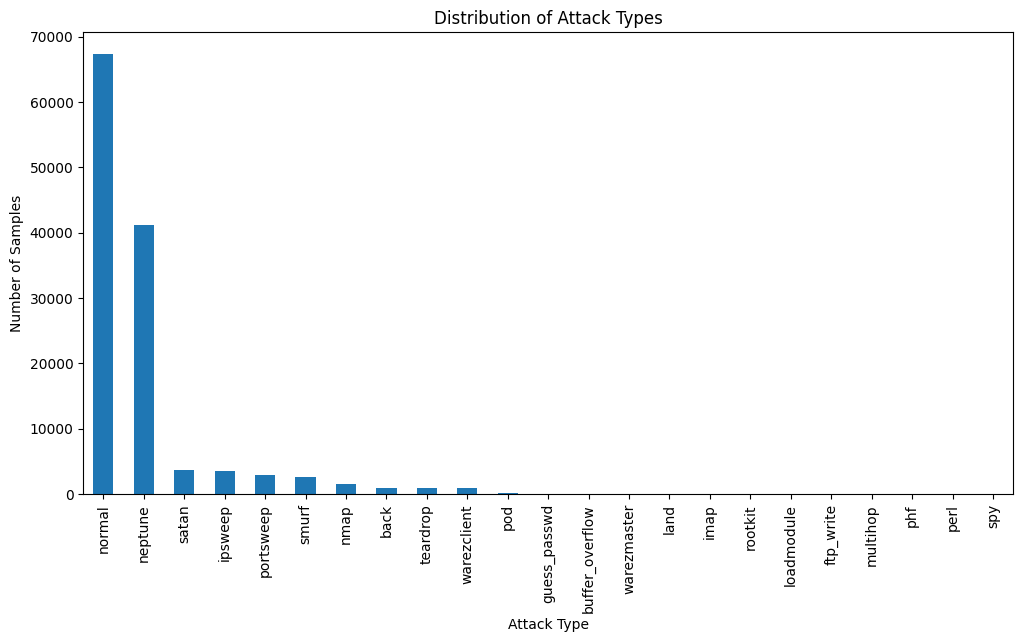

In [ ]:
labelCounts = trainData["label"].value_counts()

plt.figure(figsize=(12,6))
labelCounts.plot(kind="bar")

plt.title("Distribution of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Samples")

plt.xticks(rotation=90)

plt.show()

In [ ]:
print(trainData["label"].nunique())

23


In [ ]:
trainData["label"].value_counts().head(10)

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


### Attack Class Distribution

I started by exploring the distribution of the attack classes in the training dataset.

The dataset contains 23 different classes, including one normal traffic class and multiple attack types.

From the results, I noticed that the dataset is highly imbalanced. The normal class is the largest one with 67,343 samples, followed by the neptune attack with 41,214 samples. On the other hand, several attack classes contain only a small number of samples.

This imbalance may affect the performance of machine learning models because they usually learn better from the majority classes than from the minority ones. This observation helps explain why the paper applies techniques to handle class imbalance before training the models.
In a real intrusion detection system, this imbalance means that some attack types occur much less frequently than others. As a result, a model may achieve high overall accuracy while still failing to detect rare but important attacks.

This indicates a class imbalance problem rather than a data quality issue. The authors addressed this challenge later in the paper by applying SVM-SMOTE during the multi-class classification stage to improve the representation of the minority attack classes.

### Feature Types

To better understand the dataset, I checked the data types of all features. This helps me identify which features are numerical and which ones will require encoding before training the machine learning models.

In [ ]:
trainData.dtypes.value_counts()

,count
int64,24
float64,15
object,4



The dataset contains both numerical and categorical data.

Most of the features are numerical, including integer and floating-point values. In addition, the dataset contains four columns with the object data type. Three of them (protocolType, service and flag) are categorical features, while the label column represents the target class.

Before training the machine learning models, the categorical features will need to be converted into numerical values.

### Class Imbalance Analysis

Class imbalance is an important challenge in intrusion detection because some attack types occur much less frequently than others.

When a dataset is highly imbalanced, machine learning models tend to favor the majority classes while ignoring rare attacks. This may lead to poor detection of important security threats.

Therefore, analyzing the class distribution helps us understand the difficulty of the classification task and whether additional techniques are needed to handle imbalance.

### Numerical Feature Distribution


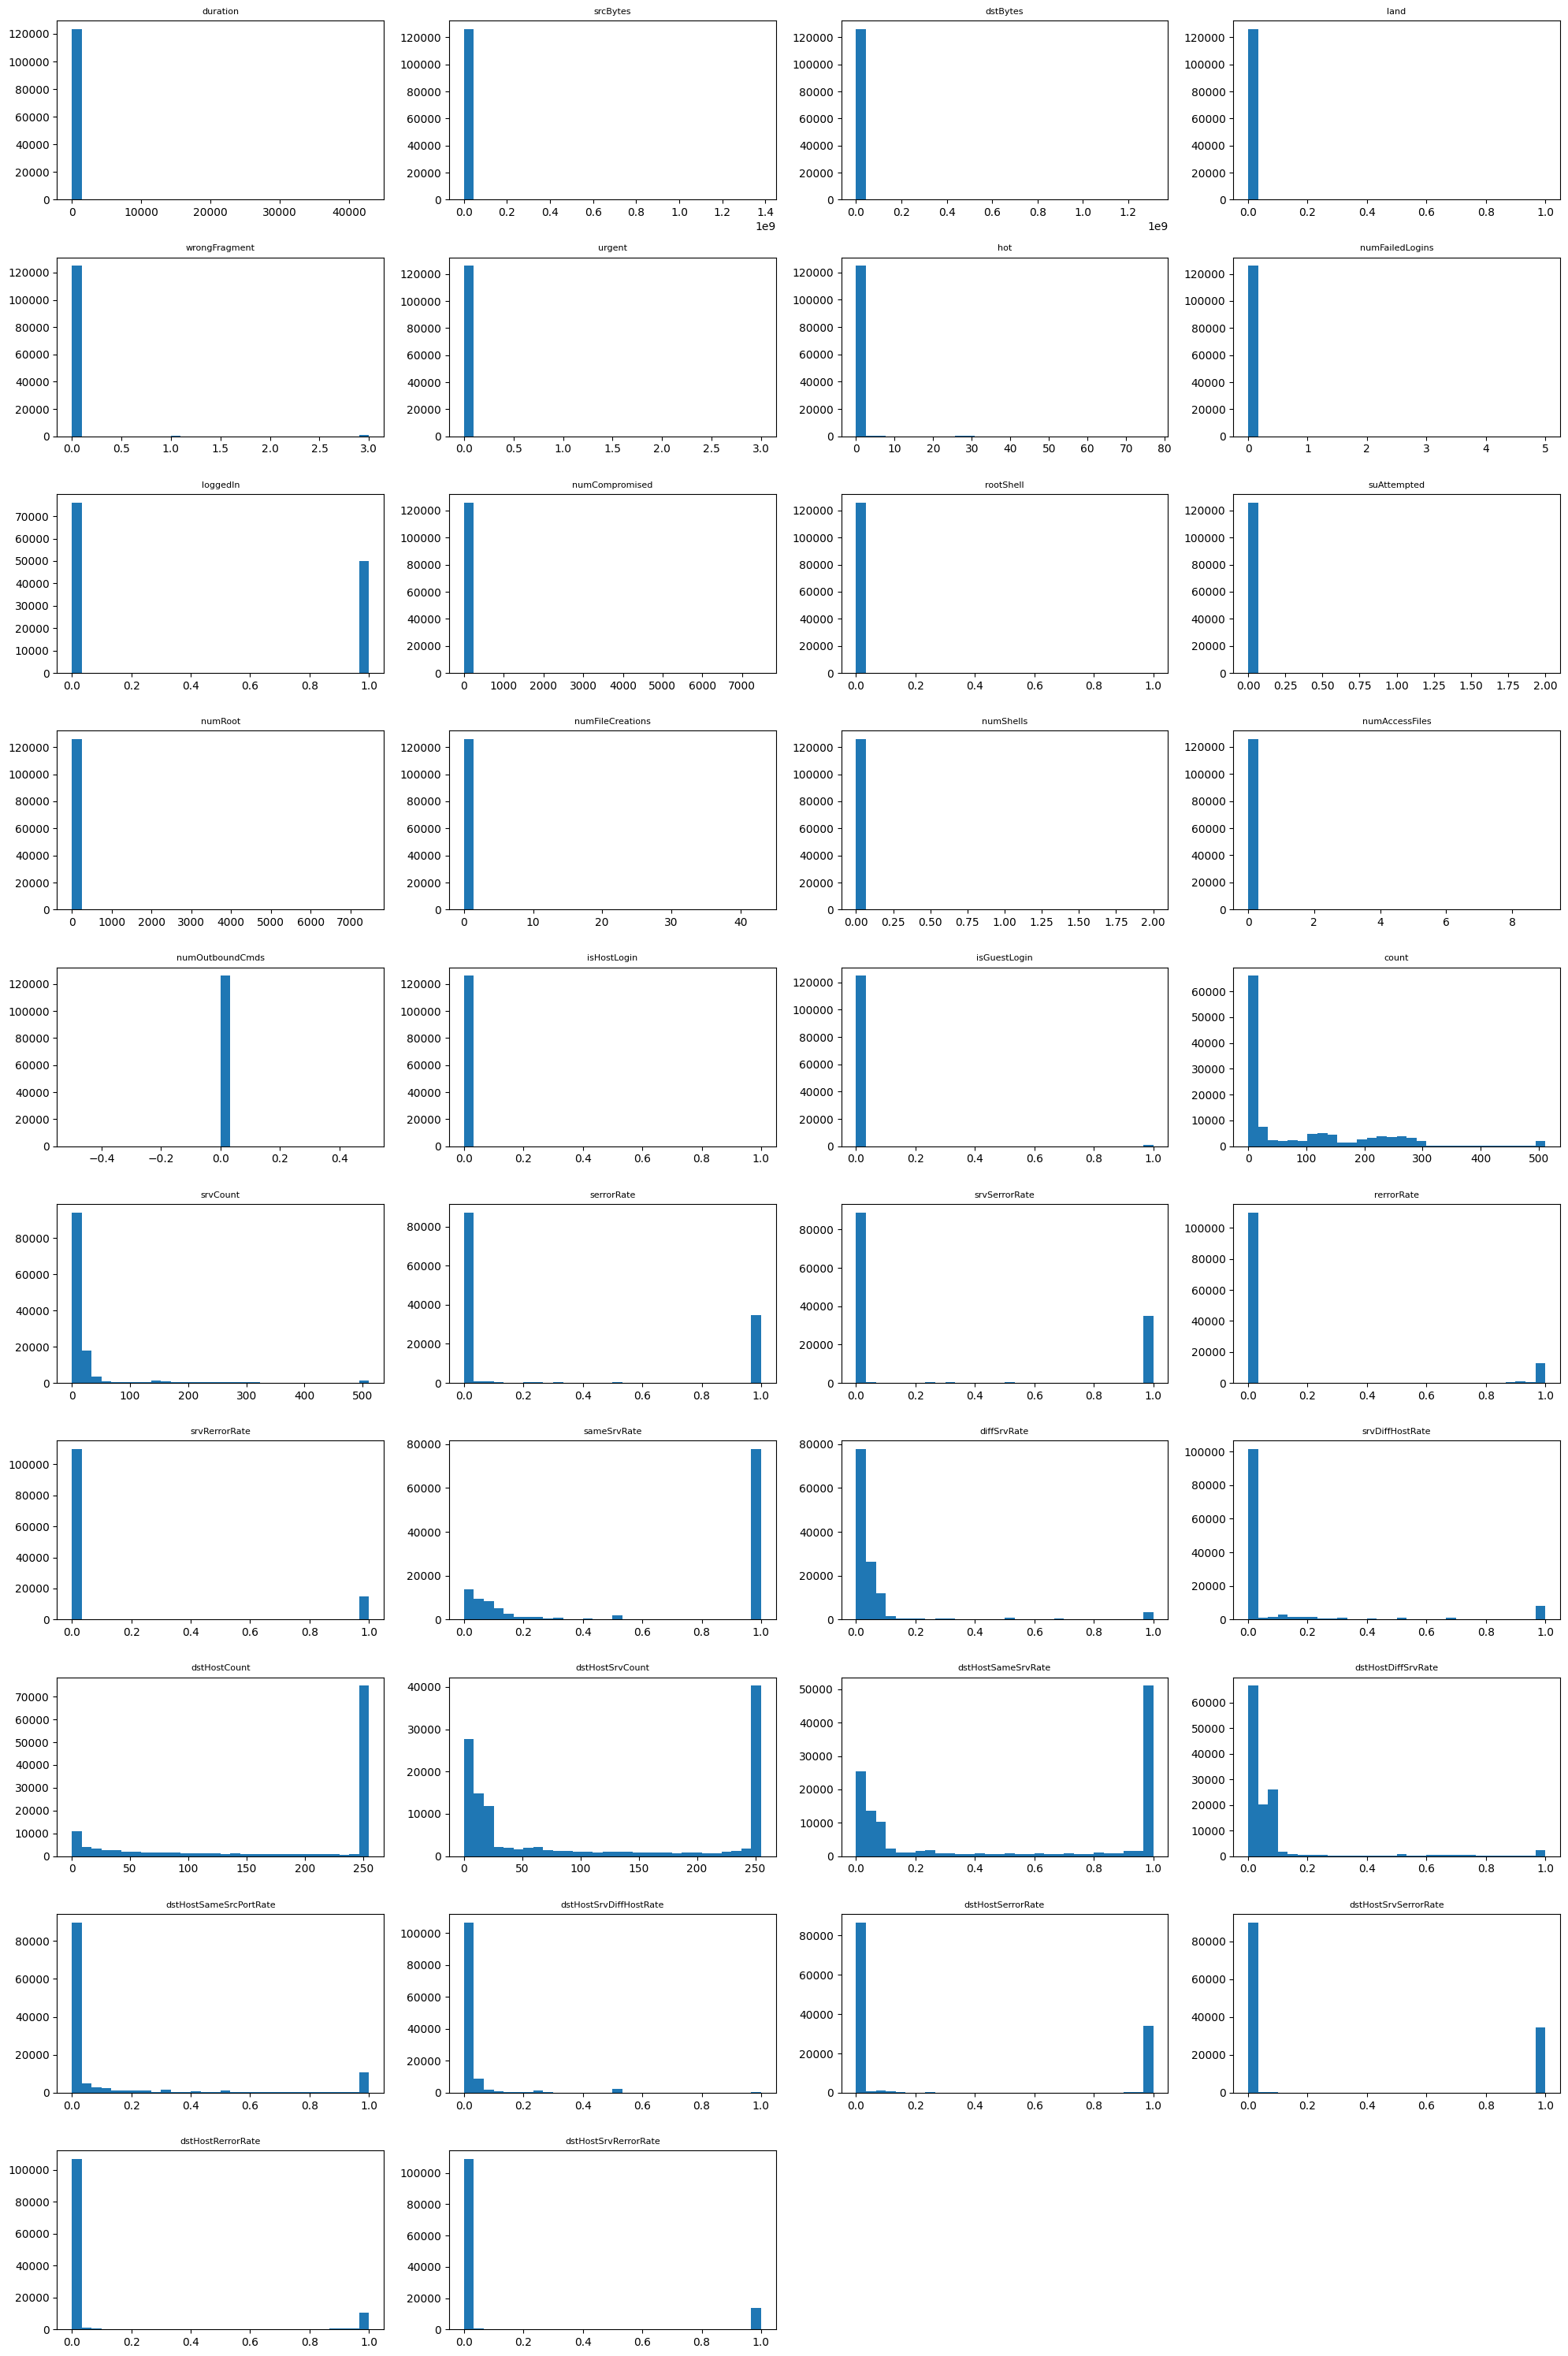

In [ ]:
numericFeatures=trainData.select_dtypes(
    include=["int64","float64"]
).columns.drop("difficulty")

rows=int(np.ceil(len(numericFeatures)/4))

plt.figure(figsize=(20,rows*3))

for i,feature in enumerate(numericFeatures):

    plt.subplot(rows,4,i+1)

    plt.hist(trainData[feature],bins=30)

    plt.title(feature,fontsize=8)



plt.tight_layout()

plt.show()



To obtain a complete overview of the dataset, I explored the distribution of all numerical features.

The histograms show that the numerical features have different distribution patterns. Many features are highly right-skewed, meaning that most observations are concentrated near zero while only a few have large values. Other features are binary or almost constant, indicating that the corresponding network events occur very rarely.

This analysis provides a better understanding of the characteristics of the dataset before the preprocessing stage. It also highlights that the numerical features have different scales and distributions, supporting the need for feature scaling later in the project.

The distribution shows that the original NSL-KDD dataset is not balanced. Some attack categories contain many samples, while others contain only a small number of observations.

This imbalance is especially important for the multi-class classification problem. In this project, the binary classification task groups all attack categories into a single attack class, which reduces the imbalance compared to the original dataset.

The paper also discusses this issue and applies SVM-SMOTE during the multi-class stage to address the severe class imbalance.

### Correlation Analysis



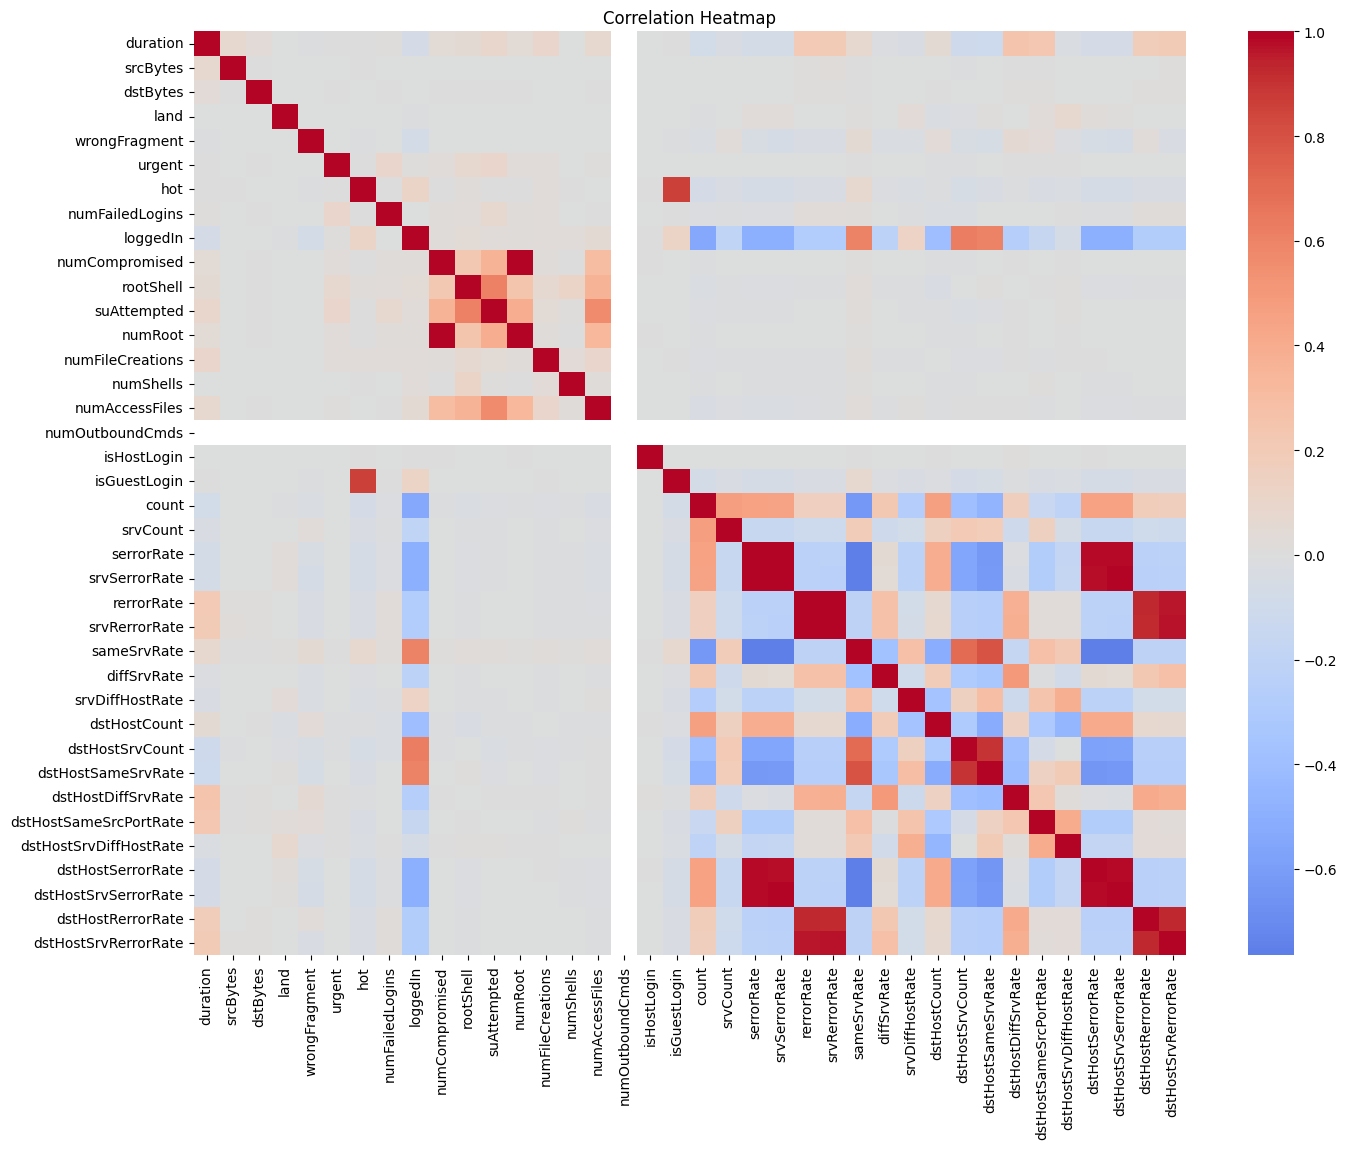

In [ ]:
numericData=trainData.select_dtypes(
    include=["int64","float64"]
).drop(columns=["difficulty"])

correlationMatrix=numericData.corr(method="pearson")

plt.figure(figsize=(16,12))

sns.heatmap(
    correlationMatrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()



To better understand the relationships between the numerical features, I calculated the Pearson correlation matrix and visualized it using a heatmap.

The Pearson correlation coefficient measures the strength and direction of the linear relationship between two numerical features. Correlation values range from -1 to 1, where values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate little or no linear relationship.

The heatmap shows that while many features have weak correlations, several groups of features are strongly correlated with one another. This is expected because some network statistics describe related aspects of the same network connections.

I chose the Pearson correlation coefficient because the goal of this analysis is to examine linear relationships between numerical features before preprocessing and model training. This helps identify features that may contain similar information and provides a better understanding of the dataset structure.

### Crosstab Analysis

Besides correlation analysis, it is useful to examine the relationship between categorical features and the attack labels.

A crosstab summarizes how frequently each protocol type appears across the different network traffic classes.

In [ ]:
protocolTable=pd.crosstab(
    trainData["protocolType"],
    trainData["label"]
)

protocolTable

label,back,buffer_overflow,ftp_write,guess_passwd,imap,ipsweep,land,loadmodule,multihop,neptune,...,phf,pod,portsweep,rootkit,satan,smurf,spy,teardrop,warezclient,warezmaster
protocolType,,,,,,,,,,,,,,,,,,,,,
icmp,0,0,0,0,0,3117,0,0,0,0,...,0,201,5,0,32,2646,0,0,0,0
tcp,956,30,8,53,11,482,18,9,7,41214,...,4,0,2926,7,2184,0,2,0,890,20
udp,0,0,0,0,0,0,0,0,0,0,...,0,0,0,3,1417,0,0,892,0,0


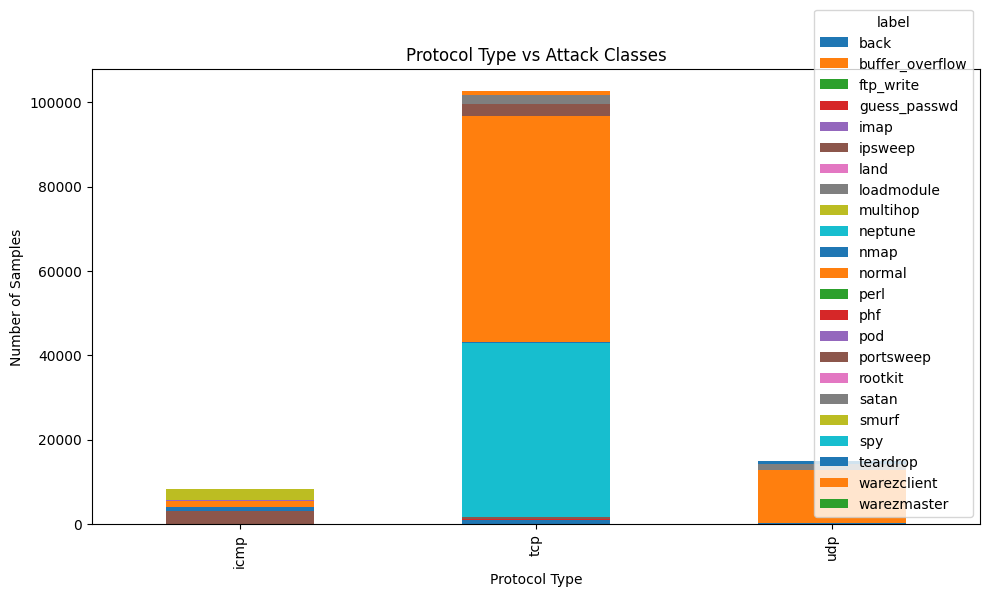

In [ ]:
protocolTable.index=["icmp","tcp","udp"]

protocolTable.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Protocol Type vs Attack Classes")
plt.xlabel("Protocol Type")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

The crosstab confirms that different protocol types are associated with different attack categories.

Most attacks are transmitted through the TCP protocol, while ICMP contains several denial-of-service attacks such as smurf and ipsweep. UDP is associated with a smaller number of attack categories.

These observations indicate that the protocol type provides useful information for distinguishing between normal and malicious network traffic and can improve intrusion detection performance.

### Boxplot Analysis


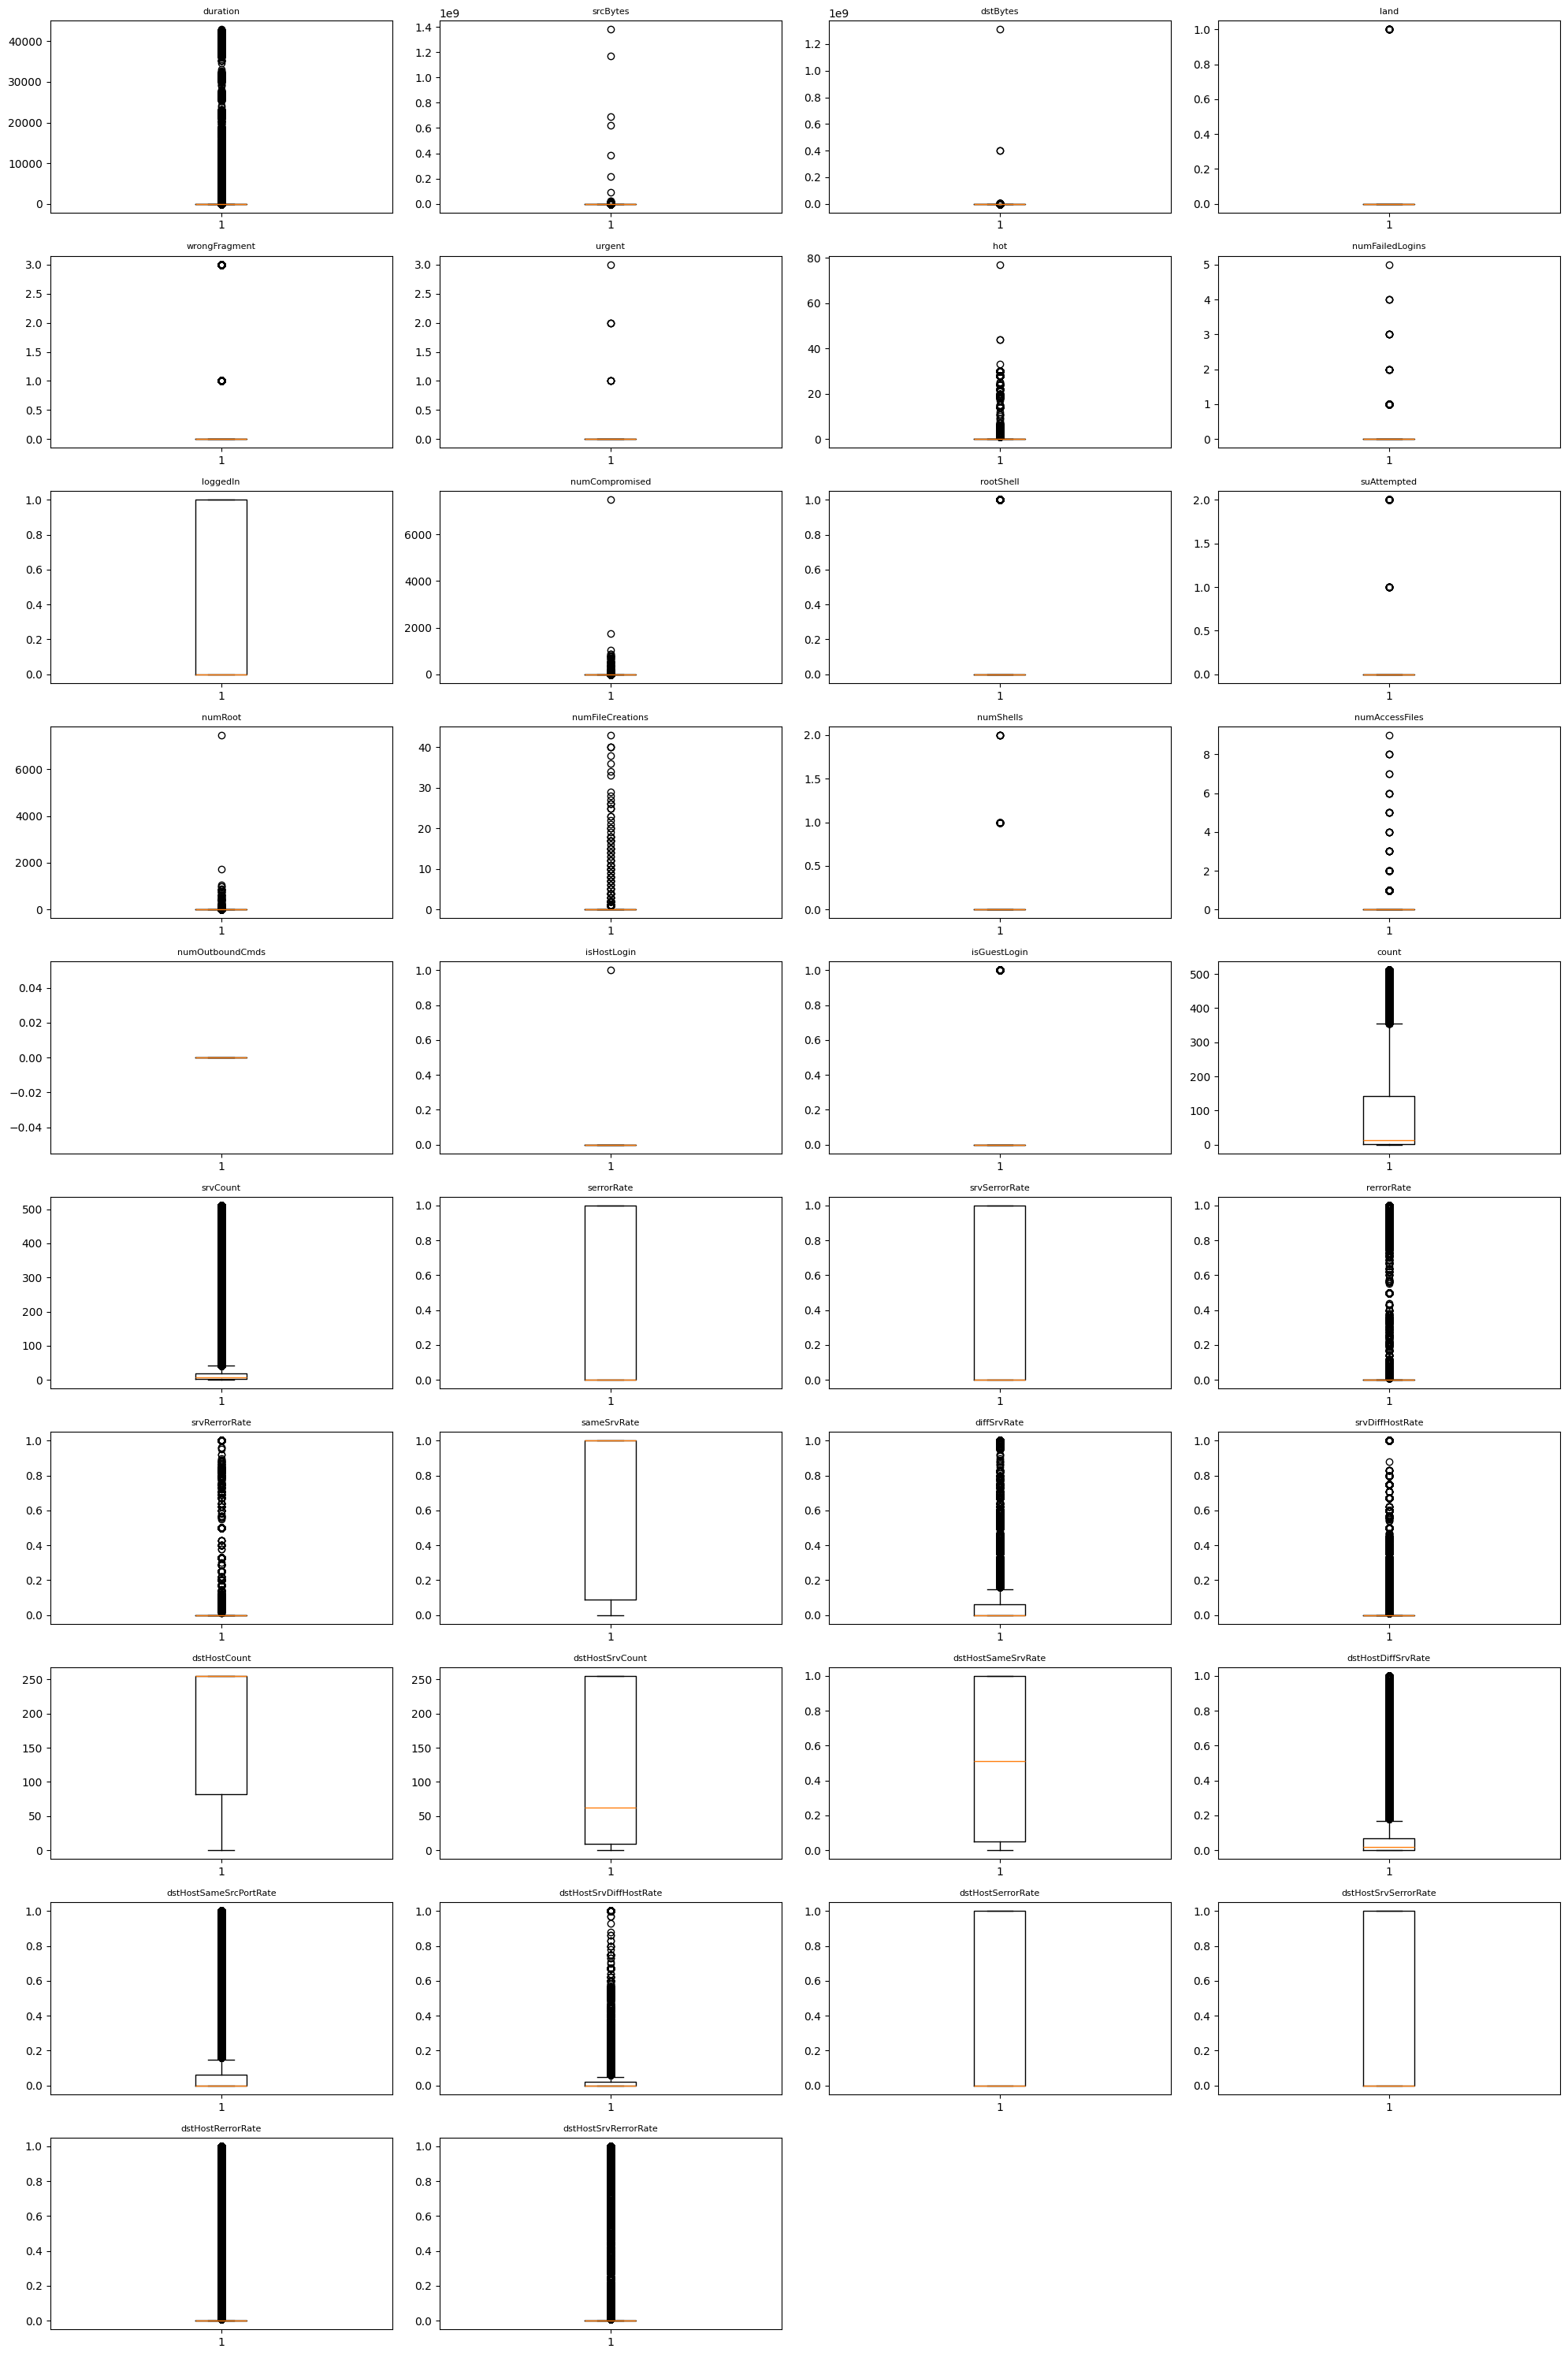

In [ ]:
numericFeatures=trainData.select_dtypes(
    include=["int64","float64"]
).columns.drop("difficulty")

rows=int(np.ceil(len(numericFeatures)/4))

plt.figure(figsize=(20,rows*3))

for i,feature in enumerate(numericFeatures):

    plt.subplot(rows,4,i+1)

    plt.boxplot(trainData[feature])

    plt.title(feature,fontsize=8)


plt.tight_layout()

plt.show()

### Outlier Analysis

To further investigate the numerical features, I created boxplots for all numerical features in the dataset.

The boxplots reveal different distribution patterns across the features. Several variables contain many extreme values and long tails, while others have very limited variability or behave as binary features.

In network intrusion detection, these extreme values are not necessarily errors. Instead, they may represent unusual network behavior or malicious activities. Therefore, the outliers were not removed during the EDA stage and will be considered during the preprocessing stage when appropriate.

# Data Preprocessing

After exploring the dataset, the next step is to preprocess the data before training the machine learning models.

The dataset contains categorical features, numerical features with different scales, and the target labels. In this stage, I prepare the data by encoding the categorical variables, removing unnecessary columns, creating the feature matrix and target labels, and scaling the numerical features.

These preprocessing steps follow the methodology described in the paper and ensure that the data is suitable for machine learning algorithms.

In [ ]:
trainData.dtypes

,0
duration,int64
protocolType,object
service,object
flag,object
srcBytes,int64
dstBytes,int64
land,int64
wrongFragment,int64
urgent,int64
hot,int64


### Encoding Categorical Features

The dataset contains three categorical features: protocolType, service, and flag.

Since machine learning algorithms require numerical input, these categorical features must be converted into numerical values before training the models.

The original paper applies an encoding step to transform the categorical attributes into a numerical representation. In this implementation, I use label encoding to prepare these features for the machine learning models.

In [ ]:
categoricalFeatures=[
    "protocolType",
    "service",
    "flag"
]

for feature in categoricalFeatures:

    labelEncoder=LabelEncoder()

    allValues=pd.concat([
        trainData[feature],
        testData[feature]
    ])

    labelEncoder.fit(allValues)

    trainData[feature]=labelEncoder.transform(trainData[feature])
    testData[feature]=labelEncoder.transform(testData[feature])

trainData[categoricalFeatures].head()

,protocolType,service,flag
0,1,20,9
1,2,44,9
2,1,49,5
3,1,24,9
4,1,24,9


### Encoding Results

The categorical features were successfully converted into numerical values using label encoding.

The output confirms that the protocolType, service, and flag columns now contain integer values instead of text labels. The encoder was fitted using the categories from both the training and testing datasets to ensure a consistent numerical mapping and avoid unseen categories during the transformation process.

### Preparing the Dataset

After encoding the categorical features, I prepare the dataset for model training.

The difficulty column is not used as an input feature in the machine learning models, so it is removed. Next, I separate the feature matrix (`X`) from the target labels (`y`) for both the training and testing datasets.

In [ ]:
trainData=trainData.drop(columns=["difficulty"])
testData=testData.drop(columns=["difficulty"])

xTrain=trainData.drop(columns=["label"])
yTrain=trainData["label"]

xTest=testData.drop(columns=["label"])
yTest=testData["label"]

print(xTrain.shape)
print(yTrain.shape)

print(xTest.shape)
print(yTest.shape)

(125973, 41)
(125973,)
(22544, 41)
(22544,)


### Dataset Preparation Results

The difficulty column was successfully removed because it is not used as an input feature for the machine learning models.

Next, the dataset was divided into the feature matrix (X) and the target labels (y). The training set contains **125,973** samples with **41** input features, while the testing set contains **22,544** samples with the same 41 features.

At this stage, the data is correctly organized and ready for the remaining preprocessing steps before training the models.

### Feature Standardization

The numerical features in the dataset have different ranges and scales. For example, some features contain binary values, while others represent network statistics with much larger values.

To ensure that all features contribute equally during model training, I standardize the feature matrix using StandardScaler.

This technique transforms each feature to have a mean close to 0 and a standard deviation close to 1. The scaler is fitted only on the training data and then applied to the testing data to prevent data leakage.

In [ ]:
scaler=StandardScaler()

xTrain=scaler.fit_transform(xTrain)
xTest=scaler.transform(xTest)

print(xTrain.shape)
print(xTest.shape)

print(xTrain.mean())
print(xTrain.std())

(125973, 41)
(22544, 41)
-5.2318489929910665e-18
0.98772959664959


In [ ]:
print(np.round(xTrain.mean(axis=0),4))
print(np.round(xTrain.std(axis=0),4))

[ 0. -0.  0.  0. -0.  0. -0.  0.  0. -0.  0.  0. -0.  0. -0.  0. -0.  0.
 -0.  0. -0.  0. -0.  0.  0. -0.  0. -0. -0. -0. -0. -0. -0. -0. -0.  0.
  0.  0. -0.  0.  0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Standardization Results

The feature matrix was successfully standardized using StandardScaler.

The number of samples and features remained unchanged after the transformation, confirming that only the feature values were modified.

The verification step shows that the standardized training features have a mean close to **0** and a standard deviation close to **1**, confirming that the scaling process was applied correctly.

This preprocessing step helps machine learning algorithms converge more efficiently and prevents features with larger numerical ranges from dominating the learning process.

### Binary Label Conversion

The first stage of the proposed approach focuses on binary intrusion detection.

To match the methodology described in the paper, I convert the target labels into two classes. The normal class represents legitimate network traffic, while all attack categories are grouped into a single attack class.

This transformation simplifies the initial classification task into distinguishing between normal and malicious network traffic.

In [ ]:
yTrainBinary=yTrain.copy()
yTestBinary=yTest.copy()

yTrainBinary=np.where(yTrainBinary=="normal",0,1)
yTestBinary=np.where(yTestBinary=="normal",0,1)

print(pd.Series(yTrainBinary).value_counts())
print()
print(pd.Series(yTestBinary).value_counts())

0    67343
1    58630
Name: count, dtype: int64

1    12833
0     9711
Name: count, dtype: int64


### Binary Label Conversion Results

The target labels were successfully converted into a binary classification problem.

The normal class was mapped to 0, while all attack categories were grouped into a single attack class and mapped to 1.

The resulting distribution shows that the binary classes are relatively balanced, making the first classification task more suitable for machine learning algorithms. This step follows the methodology presented in the paper, where intrusion detection is first treated as a binary classification problem before moving to attack categorization.

## Decision Tree Classifier

To obtain a better Decision Tree model, I use GridSearchCV to search for the best combination of hyperparameters.

Grid Search evaluates multiple parameter combinations using cross-validation and automatically selects the model that achieves the best validation performance.

This follows the methodology of the paper, where machine learning models are optimized before evaluation.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef

In [ ]:
decisionTreeParameters={
    "criterion":["gini","entropy"],
    "max_depth":[5,10,15,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

decisionTreeSearch=GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=decisionTreeParameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

decisionTreeSearch.fit(xTrain,yTrainBinary)

decisionTree=decisionTreeSearch.best_estimator_

print(decisionTreeSearch.best_params_)
print()
print(decisionTreeSearch.best_score_)

{'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

0.9982853520266775


In [ ]:
decisionTreePrediction=decisionTree.predict(xTest)

accuracy=accuracy_score(yTestBinary,decisionTreePrediction)
precision=precision_score(yTestBinary,decisionTreePrediction)
recall=recall_score(yTestBinary,decisionTreePrediction)
f1=f1_score(yTestBinary,decisionTreePrediction)
decisionTreeProbability=decisionTree.predict_proba(xTest)[:,1]
rocAuc=roc_auc_score(
    yTestBinary,
    decisionTreeProbability
)
mcc=matthews_corrcoef(
    yTestBinary,
    decisionTreePrediction
)
print("ROC-AUC :",rocAuc)
print("MCC     :",mcc)
print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

ROC-AUC : 0.8045575015557337
MCC     : 0.6201903493768701
Accuracy : 0.7801632363378282
Precision: 0.9653787073141912
Recall   : 0.6366399127250059
F1 Score : 0.7672802404207363


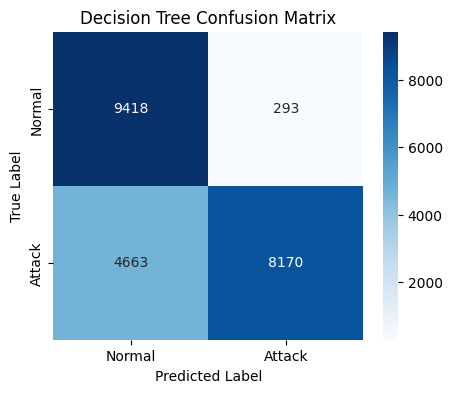

In [ ]:
decisionTreeConfusionMatrix=confusion_matrix(
    yTestBinary,
    decisionTreePrediction
)

plt.figure(figsize=(5,4))

sns.heatmap(
    decisionTreeConfusionMatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    yTestBinary,
    decisionTreePrediction,
    target_names=["Normal","Attack"]
))

              precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



In [ ]:
results=[]

In [ ]:
results.append({
    "Model":"Decision Tree",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC-AUC":rocAuc,
    "MCC":mcc
})

### Decision Tree Results

After applying hyperparameter tuning with GridSearchCV, the Decision Tree achieved an accuracy of approximately **78.0%** on the binary intrusion detection task.

The optimized model maintained a very high precision (**96.5%**), indicating that attack predictions were usually correct. However, the recall remained relatively low (**63.7%**), showing that a significant number of attack instances were still missed.

The confusion matrix confirms that the model correctly classified most normal connections while producing very few false alarms. Nevertheless, many attack samples were incorrectly classified as normal traffic, which reduced the overall recall.

Overall, hyperparameter tuning did not significantly improve the Decision Tree performance, suggesting that this model has limitations for this intrusion detection task.

## Random Forest Classifier

The second model evaluated is the Random Forest classifier.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Similar to the Decision Tree, I use GridSearchCV to identify the best hyperparameter combination before evaluating the model on the binary intrusion detection task.

In [ ]:
randomForestParameters={
    "n_estimators":[100,200],
    "max_depth":[20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

randomForestSearch=GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=randomForestParameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

randomForestSearch.fit(xTrain,yTrainBinary)

randomForest=randomForestSearch.best_estimator_

print(randomForestSearch.best_params_)
print()
print(randomForestSearch.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

0.99897597186023


In [ ]:
randomForestPrediction=randomForest.predict(xTest)

accuracy=accuracy_score(yTestBinary,randomForestPrediction)
precision=precision_score(yTestBinary,randomForestPrediction)
recall=recall_score(yTestBinary,randomForestPrediction)
f1=f1_score(yTestBinary,randomForestPrediction)
randomForestProbability=randomForest.predict_proba(xTest)[:,1]

rocAuc=roc_auc_score(
    yTestBinary,
    randomForestProbability
)

mcc=matthews_corrcoef(
    yTestBinary,
    randomForestPrediction
)

print("ROC-AUC :",rocAuc)
print("MCC     :",mcc)

print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

ROC-AUC : 0.9620335977496873
MCC     : 0.6071764230905221
Accuracy : 0.7706706884315118
Precision: 0.9661759338118993
Recall   : 0.6187952933842438
F1 Score : 0.7544176325289759


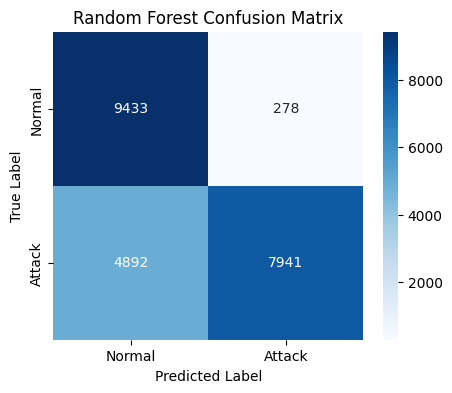

In [ ]:
randomForestConfusionMatrix=confusion_matrix(
    yTestBinary,
    randomForestPrediction
)

plt.figure(figsize=(5,4))

sns.heatmap(
    randomForestConfusionMatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    yTestBinary,
    randomForestPrediction,
    target_names=["Normal","Attack"]
))

              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
      Attack       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



In [ ]:
results.append({
    "Model":"Random Forest",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC-AUC":rocAuc,
    "MCC":mcc
})

### Random Forest Results

After hyperparameter tuning with GridSearchCV, the Random Forest classifier achieved an accuracy of approximately **77%** on the binary intrusion detection task.

The model produced a high precision (97%), indicating that most predicted attacks were correct. However, the recall remained relatively low (62%), meaning that many attack instances were still classified as normal traffic.

The confusion matrix shows that the model correctly identified most normal connections while generating only a small number of false positives. Nevertheless, a considerable number of attack samples were misclassified, which reduced both the recall and the overall F1-score.

Compared to the optimized Decision Tree, the Random Forest did not provide better performance on this dataset. This suggests that increasing model complexity alone does not necessarily improve intrusion detection accuracy.

## Linear Support Vector Machine (Linear SVM)

The final model evaluated in the binary intrusion detection stage is the Linear Support Vector Machine (Linear SVM).

A Linear SVM is a supervised learning algorithm that separates classes by finding an optimal linear decision boundary with the maximum margin between them. It is commonly used for binary classification problems and performs well on high-dimensional datasets.

Since the NSL-KDD dataset contains a large number of training samples, I used the LinearSVC implementation instead of the standard SVC implementation to improve computational efficiency. The regularization parameter (C) was optimized using GridSearchCV before evaluating the model on the testing dataset.

The optimized Linear SVM achieved an accuracy of **75.12%**. The model obtained high precision but lower recall, indicating that it correctly classified most predicted attacks while missing a noticeable portion of actual attack samples.

In [ ]:
from sklearn.svm import LinearSVC

svmParameters={
    "C":[0.1,1,10]
}

svmSearch=GridSearchCV(
    estimator=LinearSVC(
        random_state=42,
        dual=False,
        max_iter=5000
    ),
    param_grid=svmParameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svmSearch.fit(xTrain,yTrainBinary)

svm=svmSearch.best_estimator_

print(svmSearch.best_params_)
print()
print(svmSearch.best_score_)

{'C': 0.1}

0.9559429495895341


In [ ]:
svmPrediction=svm.predict(xTest)

accuracy=accuracy_score(yTestBinary,svmPrediction)
precision=precision_score(yTestBinary,svmPrediction)
recall=recall_score(yTestBinary,svmPrediction)
f1=f1_score(yTestBinary,svmPrediction)
svmScores=svm.decision_function(xTest)

rocAuc=roc_auc_score(
    yTestBinary,
    svmScores
)

mcc=matthews_corrcoef(
    yTestBinary,
    svmPrediction
)

print("ROC-AUC :",rocAuc)
print("MCC     :",mcc)

print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

ROC-AUC : 0.8701697959841733
MCC     : 0.5590018975338495
Accuracy : 0.7512420156139106
Precision: 0.9251500529598682
Recall   : 0.6125613652302657
F1 Score : 0.7370839193624004


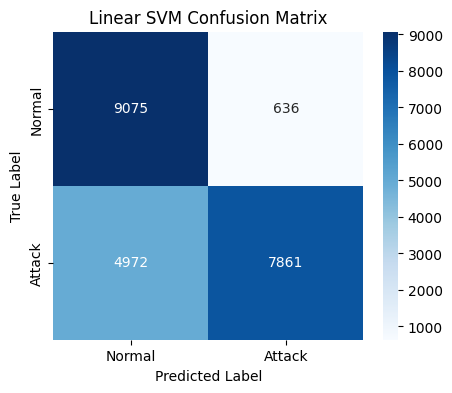

In [ ]:
svmConfusionMatrix=confusion_matrix(
    yTestBinary,
    svmPrediction
)

plt.figure(figsize=(5,4))

sns.heatmap(
    svmConfusionMatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Linear SVM Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    yTestBinary,
    svmPrediction,
    target_names=["Normal","Attack"]
))

              precision    recall  f1-score   support

      Normal       0.65      0.93      0.76      9711
      Attack       0.93      0.61      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



In [ ]:
results.append({
    "Model":"Linear SVM",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC-AUC":rocAuc,
    "MCC":mcc
})

## AdaBoost

The fourth supervised model evaluated in this project is AdaBoost (Adaptive Boosting).

AdaBoost is an ensemble learning algorithm that combines multiple weak learners, typically shallow decision trees, into a stronger classifier. During training, greater importance is assigned to samples that were previously misclassified, allowing the model to progressively improve its performance.

Following the methodology of the selected paper, AdaBoost is evaluated as one of the supervised machine learning models for binary intrusion detection. In this project, the model hyperparameters are optimized using GridSearchCV before evaluation on the testing dataset.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
paramGrid={
    "n_estimators":[50,100],
    "learning_rate":[0.5,1.0]
}

gridSearch=GridSearchCV(
    AdaBoostClassifier(random_state=42),
    paramGrid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

gridSearch.fit(xTrain, yTrainBinary)

bestModel=gridSearch.best_estimator_

print(gridSearch.best_params_)

{'learning_rate': 1.0, 'n_estimators': 100}


In [ ]:
adaBoost=gridSearch.best_estimator_

adaBoostPrediction=adaBoost.predict(xTest)

rocAuc=roc_auc_score(
    yTestBinary,
    adaBoostPrediction
)

mcc=matthews_corrcoef(
    yTestBinary,
    adaBoostPrediction
)

accuracy=accuracy_score(yTestBinary,adaBoostPrediction)
precision=precision_score(yTestBinary,adaBoostPrediction)
recall=recall_score(yTestBinary,adaBoostPrediction)
f1=f1_score(yTestBinary,adaBoostPrediction)

print("ROC-AUC :",rocAuc)
print("MCC     :",mcc)
print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

ROC-AUC : 0.8119335823133168
MCC     : 0.6340328941600073
Accuracy : 0.7904098651525905
Precision: 0.9637382749942804
Recall   : 0.6565105587158108
F1 Score : 0.7809965237543454


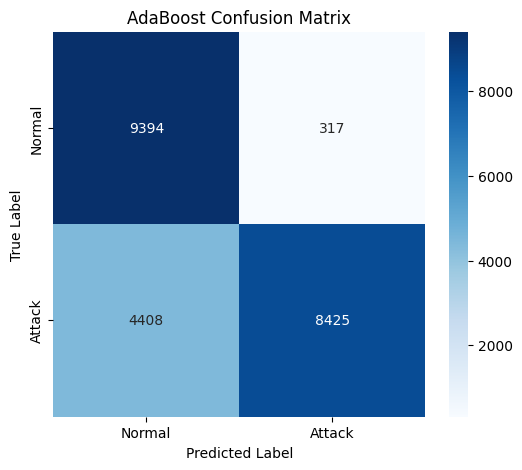

In [ ]:
adaBoostConfusionMatrix=confusion_matrix(
    yTestBinary,
    adaBoostPrediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    adaBoostConfusionMatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("AdaBoost Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    yTestBinary,
    adaBoostPrediction,
    target_names=["Normal","Attack"]
))

              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80      9711
      Attack       0.96      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



In [ ]:
results.append({
    "Model":"AdaBoost",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC-AUC":rocAuc,
    "MCC":mcc
})

### AdaBoost Results

The optimized AdaBoost model achieved excellent overall performance among the supervised learning models.

It obtained high Accuracy, Recall, F1-score, Precision, and MCC, making it one of the strongest supervised classifiers evaluated in this project.

These results indicate that AdaBoost provides an effective balance between correctly detecting attacks and minimizing classification errors on the NSL-KDD dataset.

## Gradient Boosting

The next supervised model evaluated in the binary intrusion detection stage is Gradient Boosting.

Gradient Boosting is an ensemble learning algorithm that builds a sequence of decision trees, where each new tree attempts to correct the errors made by the previous trees. This sequential learning process usually improves predictive performance and reduces classification errors.

Following the methodology of the selected paper, the model hyperparameters are optimized using GridSearchCV before evaluating the model on the testing dataset.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gradientBoostingParameters={
    "n_estimators":[100,200],
    "learning_rate":[0.05,0.1],
    "max_depth":[3,5]
}

gradientBoostingSearch=GridSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=42
    ),
    param_grid=gradientBoostingParameters,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

gradientBoostingSearch.fit(
    xTrain,
    yTrainBinary
)

gradientBoosting=gradientBoostingSearch.best_estimator_

print(gradientBoostingSearch.best_params_)
print()
print(gradientBoostingSearch.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

0.9987219483540124


In [ ]:
gradientBoostingPrediction=gradientBoosting.predict(xTest)

rocAuc=roc_auc_score(
    yTestBinary,
    gradientBoostingPrediction
)

mcc=matthews_corrcoef(
    yTestBinary,
    gradientBoostingPrediction
)

accuracy=accuracy_score(
    yTestBinary,
    gradientBoostingPrediction
)

precision=precision_score(
    yTestBinary,
    gradientBoostingPrediction
)

recall=recall_score(
    yTestBinary,
    gradientBoostingPrediction
)

f1=f1_score(
    yTestBinary,
    gradientBoostingPrediction
)

print("ROC-AUC :",rocAuc)
print("MCC     :",mcc)
print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

ROC-AUC : 0.800321575139228
MCC     : 0.6155770517419042
Accuracy : 0.7767476933995742
Precision: 0.9658385093167702
Recall   : 0.6300942881633289
F1 Score : 0.7626503183211507


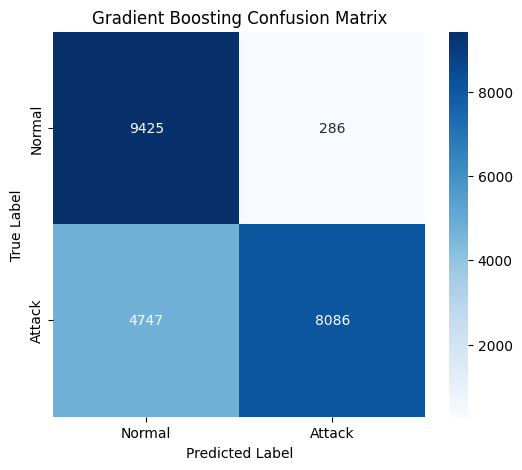

In [ ]:
gradientBoostingConfusionMatrix=confusion_matrix(
    yTestBinary,
    gradientBoostingPrediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    gradientBoostingConfusionMatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Gradient Boosting Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    yTestBinary,
    gradientBoostingPrediction,
    target_names=["Normal","Attack"]
))

              precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544



In [ ]:
results.append({
    "Model":"Gradient Boosting",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC-AUC":rocAuc,
    "MCC":mcc
})

The optimized Gradient Boosting model achieved strong classification performance on the binary intrusion detection task.

The model obtained an accuracy of approximately **77.7%**, together with high precision and good overall performance across the remaining evaluation metrics. Although Gradient Boosting performed well, its overall results were slightly lower than those obtained by AdaBoost in this implementation.

These results indicate that Gradient Boosting is an effective ensemble learning method, but for the NSL-KDD dataset used in this project, AdaBoost provided a better overall balance between attack detection and classification accuracy.

## Multi-Layer Perceptron (MLP)

The next supervised model evaluated in the binary intrusion detection stage is the Multi-Layer Perceptron (MLP).

MLP is a feed-forward artificial neural network consisting of multiple fully connected layers. It is capable of learning complex non-linear relationships between features and is widely used for classification tasks.

Following the methodology of the selected paper, the model hyperparameters are optimized using GridSearchCV before evaluating the model on the testing dataset.

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
mlpParameters={
    "hidden_layer_sizes":[
        (100,),
        (100,50)
    ],
    "activation":[
        "relu",
        "tanh"
    ],
    "alpha":[
        0.0001,
        0.001
    ]
}

mlpSearch=GridSearchCV(
    estimator=MLPClassifier(
        random_state=42,
        max_iter=300
    ),
    param_grid=mlpParameters,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

mlpSearch.fit(
    xTrain,
    yTrainBinary
)

mlp=mlpSearch.best_estimator_

print(mlpSearch.best_params_)
print()
print(mlpSearch.best_score_)

{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,)}

0.9964913116302699


In [ ]:
mlpPrediction=mlp.predict(xTest)

rocAuc=roc_auc_score(
    yTestBinary,
    mlpPrediction
)

mcc=matthews_corrcoef(
    yTestBinary,
    mlpPrediction
)

accuracy=accuracy_score(
    yTestBinary,
    mlpPrediction
)

precision=precision_score(
    yTestBinary,
    mlpPrediction
)

recall=recall_score(
    yTestBinary,
    mlpPrediction
)

f1=f1_score(
    yTestBinary,
    mlpPrediction
)

print("ROC-AUC :",rocAuc)
print("MCC     :",mcc)
print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

ROC-AUC : 0.8175317963195413
MCC     : 0.6460823629996675
Accuracy : 0.7955997161107168
Precision: 0.9730817899459335
Recall   : 0.6591599781812515
F1 Score : 0.7859332899749141


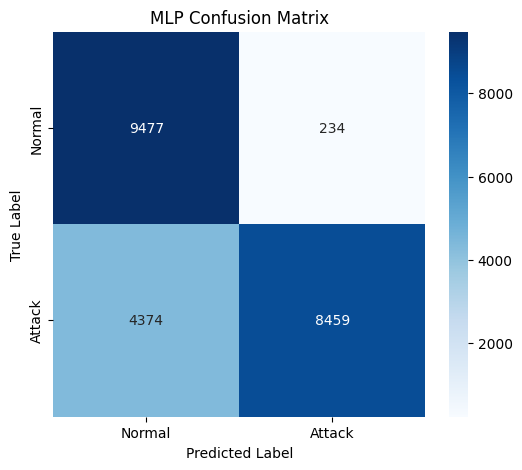

In [ ]:
mlpConfusionMatrix=confusion_matrix(
    yTestBinary,
    mlpPrediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    mlpConfusionMatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MLP Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    yTestBinary,
    mlpPrediction,
    target_names=["Normal","Attack"]
))

              precision    recall  f1-score   support

      Normal       0.68      0.98      0.80      9711
      Attack       0.97      0.66      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.79     22544



In [ ]:
results.append({
    "Model":"MLP",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC-AUC":rocAuc,
    "MCC":mcc
})

### MLP Results

The optimized Multi-Layer Perceptron (MLP) achieved the best overall performance among all supervised machine learning models evaluated in this project.

The model obtained an accuracy of approximately **79.6%**, together with high Precision, Recall, F1-score, and MCC. These results indicate that the neural network successfully learned complex relationships between the input features and provided the strongest overall performance among the supervised learning models.

The MLP results are consistent with the strong performance of neural network models reported in the selected paper.

## Autoencoder

The final model evaluated in this project is an Autoencoder-based anomaly detection model.

Unlike the previous supervised machine learning models, the Autoencoder was trained only on normal network traffic. During testing, the reconstruction error of each sample was computed, and samples with reconstruction errors above a threshold determined from the validation reconstruction loss were classified as attacks.

The implemented Autoencoder follows the methodology described in the selected paper by using Gaussian Noise, SeLU activation, Dropout, Mean Squared Error (MSE) loss, Adam optimizer, and Early Stopping. A deeper encoder-decoder architecture was implemented to improve the reconstruction of normal traffic while maintaining the overall approach proposed in the paper.

Among all evaluated models, the Autoencoder achieved the best overall performance, obtaining approximately **82% accuracy**, together with the highest Recall, F1-score, and MCC. These results demonstrate the effectiveness of anomaly detection for identifying network intrusions and are consistent with the conclusions presented in the paper.

In [ ]:
from sklearn.model_selection import train_test_split

xTrainNormal=xTrain[yTrainBinary==0]

xTrainAe,xValidationAe=train_test_split(
    xTrainNormal,
    test_size=0.15,
    random_state=42
)

print(xTrainAe.shape)
print(xValidationAe.shape)
print(xTest.shape)

(57241, 41)
(10102, 41)
(22544, 41)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense,GaussianNoise,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

inputLayer=Input(shape=(41,))

x=GaussianNoise(0.15)(inputLayer)

x=Dense(32,activation="selu")(x)
x=Dropout(0.05)(x)

x=Dense(15,activation="selu")(x)
x=Dropout(0.05)(x)

x=Dense(32,activation="selu")(x)

outputLayer=Dense(41,activation="linear")(x)

autoencoder=Model(inputLayer,outputLayer)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           495 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,704 (14.47 KB)

 Trainable params: 3,704 (14.47 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
earlyStopping=EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

history=autoencoder.fit(
    xTrainAe,
    xTrainAe,
    epochs=100,
    batch_size=32,
    validation_data=(xValidationAe,xValidationAe),
    callbacks=[earlyStopping],
    verbose=1
)

Epoch 1/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.3728 - val_loss: 0.5354
Epoch 2/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2264 - val_loss: 0.4796
Epoch 3/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1894 - val_loss: 0.4880
Epoch 4/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1708 - val_loss: 0.4419
Epoch 5/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1530 - val_loss: 0.4074
Epoch 6/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1400 - val_loss: 0.4064
Epoch 7/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1248 - val_loss: 0.3952
Epoch 8/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1216 - val_loss: 0.4175
Epoch 9/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1100 - val_loss: 0.4035
Epoch 10/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1015 - val_loss: 0.4112
Epoch 11/100
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0842 - val_loss: 0.4257
Epoch 12/100
1789/

In [ ]:
validationPrediction=autoencoder.predict(xValidationAe)

validationLoss=np.mean(
    np.square(xValidationAe-validationPrediction),
    axis=1
)

threshold=np.percentile(validationLoss,95)

print("Threshold:",threshold)

316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Threshold: 0.1156262956808915


In [ ]:
testPrediction=autoencoder.predict(xTest)

testLoss=np.mean(
    np.square(xTest-testPrediction),
    axis=1
)

autoencoderPrediction=(testLoss>threshold).astype(int)

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
rocAuc=roc_auc_score(yTestBinary,testLoss)
mcc=matthews_corrcoef(yTestBinary,autoencoderPrediction)

accuracy=accuracy_score(yTestBinary,autoencoderPrediction)
precision=precision_score(yTestBinary,autoencoderPrediction)
recall=recall_score(yTestBinary,autoencoderPrediction)
f1=f1_score(yTestBinary,autoencoderPrediction)

print("ROC-AUC :",rocAuc)
print("MCC     :",mcc)
print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

ROC-AUC : 0.9313223017166821
MCC     : 0.6717119925566776
Accuracy : 0.8258073101490419
Precision: 0.930407887106128
Recall   : 0.7500974051274059
F1 Score : 0.8305794037706544


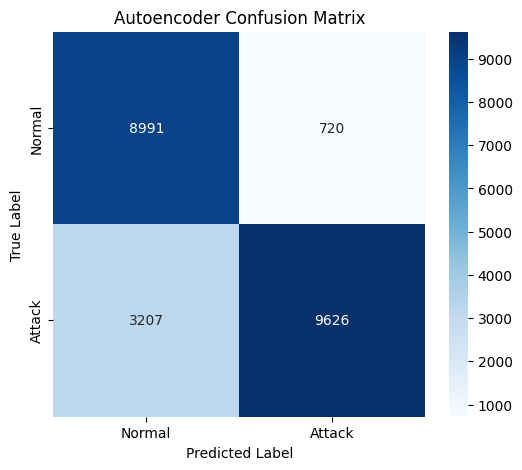

In [ ]:
autoencoderConfusionMatrix=confusion_matrix(
    yTestBinary,
    autoencoderPrediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    autoencoderConfusionMatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Autoencoder Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    yTestBinary,
    autoencoderPrediction,
    target_names=["Normal","Attack"]
))

              precision    recall  f1-score   support

      Normal       0.74      0.93      0.82      9711
      Attack       0.93      0.75      0.83     12833

    accuracy                           0.83     22544
   macro avg       0.83      0.84      0.83     22544
weighted avg       0.85      0.83      0.83     22544



In [ ]:
results.append({
    "Model":"Autoencoder",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1,
    "ROC-AUC":rocAuc,
    "MCC":mcc
})

## Evaluation Metrics

Several evaluation metrics were used to assess the performance of the intrusion detection models.

**Accuracy** measures the overall proportion of correctly classified samples.

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

Although Accuracy provides a general indication of model performance, it may be misleading when the dataset is imbalanced.

**Precision** measures how many predicted attacks are actually attacks.

$$
Precision=\frac{TP}{TP+FP}
$$

High Precision reduces the number of false alarms (False Positives), allowing security analysts to focus on real threats.

**Recall** measures how many real attacks are successfully detected.

$$
Recall=\frac{TP}{TP+FN}
$$

Recall is one of the most important metrics in intrusion detection because False Negatives represent real attacks that remain undetected and may compromise the system.

**F1-score** combines Precision and Recall into a single metric using their harmonic mean.

$$
F1=2\cdot\frac{Precision\times Recall}{Precision+Recall}
$$

F1-score is particularly useful when both Precision and Recall are important, providing a balanced evaluation of the classifier.

**ROC-AUC (Receiver Operating Characteristic – Area Under the Curve)** evaluates the ability of a classifier to distinguish between normal and attack traffic across all possible classification thresholds. A higher ROC-AUC indicates better discrimination capability regardless of the selected threshold.

**Matthews Correlation Coefficient (MCC)** evaluates the overall quality of binary classification by considering all four outcomes of the confusion matrix (TP, TN, FP, and FN).

$$
MCC=\frac{TP\times TN-FP\times FN}
{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
$$

MCC is especially useful for intrusion detection because it remains reliable even when the dataset is imbalanced.

The **Confusion Matrix** summarizes the numbers of **True Positives (TP)**, **True Negatives (TN)**, **False Positives (FP)**, and **False Negatives (FN)**, allowing detailed analysis of classification errors.

In intrusion detection, **False Positives** generate unnecessary security alerts, while **False Negatives** are usually much more severe because real attacks remain undetected. Therefore, several complementary evaluation metrics were used instead of relying only on Accuracy.

## Model Comparison

After evaluating all seven machine learning models, I compare their performance using six evaluation metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC, and MCC.

The comparison provides a clear overview of the strengths and weaknesses of each model and helps identify the most suitable approach for the binary intrusion detection task.

In [ ]:
results=pd.DataFrame(results)

results=results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,MCC
0,Decision Tree,0.7802,0.9654,0.6366,0.7673,0.8046,0.6202
1,Random Forest,0.7707,0.9662,0.6188,0.7544,0.9620,0.6072
2,Linear SVM,0.7512,0.9252,0.6126,0.7371,0.8702,0.5590
3,AdaBoost,0.7904,0.9637,0.6565,0.7810,0.8119,0.6340
4,Gradient Boosting,0.7767,0.9658,0.6301,0.7627,0.8003,0.6156
5,MLP,0.7956,0.9731,0.6592,0.7859,0.8175,0.6461
6,Autoencoder,0.8258,0.9304,0.7501,0.8306,0.9313,0.6717


## Performance Comparison

To better compare the performance of all evaluated models, I visualize the six evaluation metrics using a grouped bar chart.

The comparison includes Decision Tree, Random Forest, Linear SVM, AdaBoost, Gradient Boosting, MLP, and the Autoencoder.

The visualization provides an intuitive comparison of the strengths and weaknesses of each model across Accuracy, Precision, Recall, F1-score, ROC-AUC, and MCC.

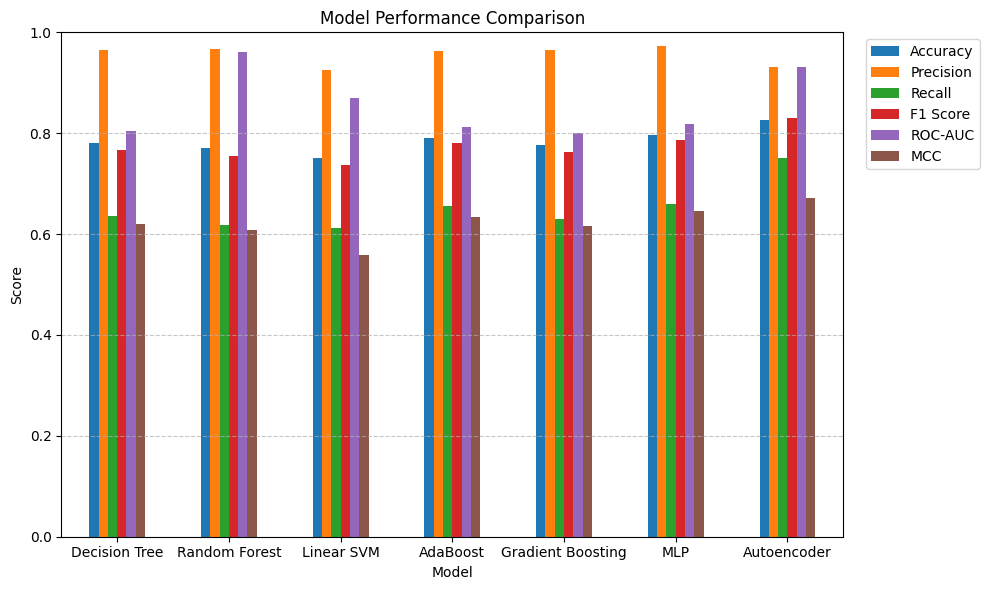

In [ ]:
results.plot(
    x="Model",
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02,1)
)

plt.tight_layout()

plt.show()

## Results Discussion

The comparison demonstrates that each model has different strengths.

The Autoencoder achieved the best overall performance, obtaining the highest Accuracy, Recall, F1-score, MCC, and one of the highest ROC-AUC values. These results indicate that reconstruction-based anomaly detection is highly effective for binary intrusion detection on the NSL-KDD dataset.

Among the supervised learning models, the Multi-Layer Perceptron (MLP) achieved the strongest overall performance, followed closely by AdaBoost.

Random Forest achieved the highest Precision and one of the highest ROC-AUC scores, indicating excellent discrimination capability while producing very few false positive predictions.

Linear SVM produced the lowest overall performance among the evaluated supervised models, although it still maintained relatively high Precision.

Overall, the experimental results demonstrate that evaluating intrusion detection models requires multiple complementary evaluation metrics, since each metric highlights a different aspect of model performance.

## Error Analysis

The confusion matrices show that most evaluated models achieved high Precision, meaning that most predicted attacks were correctly classified.

The Autoencoder significantly improved Recall compared to the supervised learning models, reducing the number of undetected attacks while maintaining high overall classification performance.

From a cybersecurity perspective, False Negatives are generally more critical than False Positives because undetected attacks may continue operating without raising security alerts.

Although False Positives increase the workload of security analysts, they are usually less harmful than allowing real attacks to remain undetected.

Overall, the Autoencoder provides the best balance between detecting attacks and minimizing classification errors.

## Comparison with the Paper

The implementation in this project follows the main binary intrusion detection pipeline presented in the selected paper. Similar preprocessing steps were applied, including categorical feature encoding, feature standardization, and binary label conversion before training the machine learning models.

The project evaluates the same supervised learning models presented in the paper, including Decision Tree, Random Forest, Linear SVM, AdaBoost, Gradient Boosting, MLP, and an Autoencoder-based anomaly detection model.

The experimental results show that the Autoencoder achieved the best overall performance in this implementation, followed by the MLP. Among the classical machine learning models, AdaBoost demonstrated the strongest overall performance, while Random Forest achieved the highest Precision and ROC-AUC.

Although the exact numerical values differ from those reported in the paper, the overall conclusions are similar. Deep learning approaches, particularly the Autoencoder, provide the strongest performance for binary intrusion detection on the NSL-KDD dataset.

## Reproducibility Analysis

The experiments presented in this project can be reproduced using the publicly available NSL-KDD dataset together with the provided notebook.

The preprocessing pipeline, including categorical feature encoding, feature scaling, binary label conversion, hyperparameter optimization, and model evaluation, is fully documented in the notebook.

However, the original paper does not provide every implementation detail. Several preprocessing decisions, hyperparameter settings, and Autoencoder design choices are not fully specified, making an exact reproduction of the published numerical results difficult.

Nevertheless, the overall experimental methodology was successfully reproduced, and the obtained results support the main conclusions presented in the paper.

## Conclusion

In this project, seven machine learning models were implemented and evaluated for binary network intrusion detection using the NSL-KDD dataset.

The evaluated models included Decision Tree, Random Forest, Linear SVM, AdaBoost, Gradient Boosting, Multi-Layer Perceptron (MLP), and an Autoencoder-based anomaly detection model. Hyperparameter optimization was performed using GridSearchCV for all supervised models, while the Autoencoder was trained only on normal traffic and detected anomalies using reconstruction error.

The Autoencoder achieved the best overall performance, obtaining the highest Accuracy, Recall, F1-score, and MCC. Random Forest achieved the highest ROC-AUC score, while MLP also demonstrated excellent classification performance.

Overall, the experimental results support the conclusions presented in the selected research paper and demonstrate that deep learning–based anomaly detection is an effective approach for binary intrusion detection.